# 🧠 Mental Health in Tech - Exploratory Data Analysis (EDA)
**Dataset Source:** 2014 Tech Workplace Mental Health Survey

**Objective:** Explore mental health attitudes, support, and challenges in the tech industry using survey data.


In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv(r"C:\Users\ramkee\Desktop\survey.csv")
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [14]:
# Overview of the dataset
print("Shape:", df.shape)
df.info()
df.describe(include='all')

Shape: (1259, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   ob

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
count,1259,1.259000e+03,1259,1259,744,1241,1259,1259,995,1259,...,1259,1259,1259,1259,1259,1259,1259,1259,1259,164
unique,1246,NaN,49,48,45,2,2,2,4,6,...,5,3,3,3,3,3,3,3,2,160
top,2014-08-27 12:43:28,NaN,Male,United States,CA,No,No,Yes,Sometimes,6-25,...,Don't know,No,No,Some of them,Yes,No,Maybe,Don't know,No,* Small family business - YMMV.
freq,2,NaN,615,751,138,1095,767,637,465,290,...,563,490,925,774,516,1008,557,576,1075,5
mean,NaN,7.942815e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,2.818299e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,-1.726000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2.700000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,3.100000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,3.600000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 🧹 Data Cleaning & Preprocessing

In [15]:
# Filter for realistic age values (already cleaned)
df = df[(df['Age'] > 16) & (df['Age'] < 100)]


# Clean and standardize gender entries
# Step 1: Reload fresh original data
df = pd.read_csv(r"C:\Users\mk199\OneDrive\Desktop\Ronak\Internship\LABMENTEX\Mental Health Survey EDA Analysis\data\survey.csv")

# Step 2: Lowercase and strip
df['Gender'] = df['Gender'].str.lower().str.strip()

# Step 3: Preview unique values BEFORE cleaning
print(df['Gender'].unique())  # ✅ This time you'll see: ['male', 'female', 'f', 'woman', ...]

# Step 4: Clean correctly
def clean_gender(g):
    if any(word in g for word in ['female', 'f', 'woman']):
        return 'female'
    elif any(word in g for word in ['male', 'm', 'man']):
        return 'male'
    elif 'trans' in g:
        return 'trans'
    else:
        return 'other'

df['Gender'] = df['Gender'].apply(clean_gender)

# Step 5: Check the final distribution
print(df['Gender'].value_counts())
df['Age'].describe()

['female' 'm' 'male' 'male-ish' 'maile' 'trans-female' 'cis female' 'f'
 'something kinda male?' 'cis male' 'woman' 'mal' 'male (cis)'
 'queer/she/they' 'non-binary' 'femake' 'make' 'nah' 'all' 'enby' 'fluid'
 'genderqueer' 'androgyne' 'agender' 'cis-female/femme' 'guy (-ish) ^_^'
 'male leaning androgynous' 'man' 'trans woman' 'msle' 'neuter'
 'female (trans)' 'queer' 'female (cis)' 'mail' 'a little about you'
 'malr' 'p' 'femail' 'cis man'
 'ostensibly male, unsure what that really means']
Gender
male      994
female    252
other      13
Name: count, dtype: int64


count    1.259000e+03
mean     7.942815e+07
std      2.818299e+09
min     -1.726000e+03
25%      2.700000e+01
50%      3.100000e+01
75%      3.600000e+01
max      1.000000e+11
Name: Age, dtype: float64

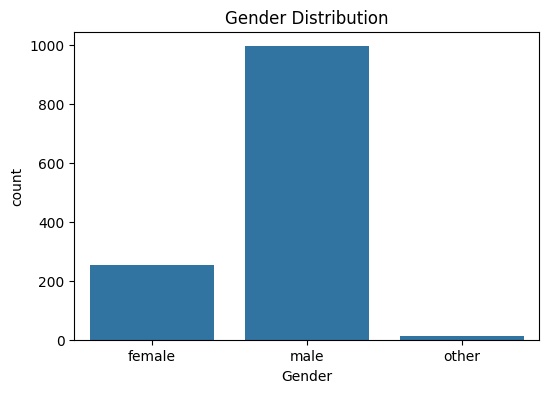

In [16]:
# Gender-based Visualizations
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.savefig(r"C:\Users\mk199\OneDrive\Desktop\Ronak\Internship\LABMENTEX\Mental Health Survey EDA Analysis\images\gender_distribution.png", bbox_inches='tight')
plt.show()


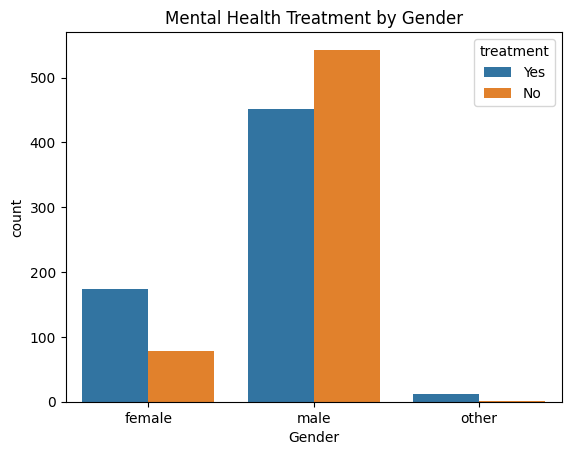

In [17]:
# Treatment vs Gender
sns.countplot(x='Gender', hue='treatment', data=df)
plt.title("Mental Health Treatment by Gender")
plt.savefig(r"C:\Users\mk199\OneDrive\Desktop\Ronak\Internship\LABMENTEX\Mental Health Survey EDA Analysis\images\Mental Health Treatment by Gender.png", bbox_inches='tight')
plt.show()


In [6]:
# Save Cleaned Dataset
df.to_csv("cleaned_survey.csv", index=False)
df = pd.read_csv(r"C:\Users\mk199\OneDrive\Desktop\Ronak\Internship\LABMENTEX\Mental Health Survey EDA Analysis\notebook\cleaned_survey.csv")


## 📊 Univariate Analysis

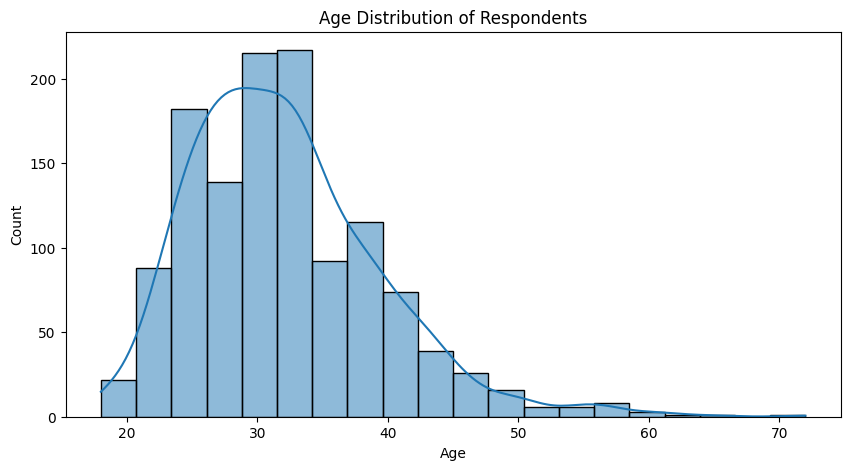

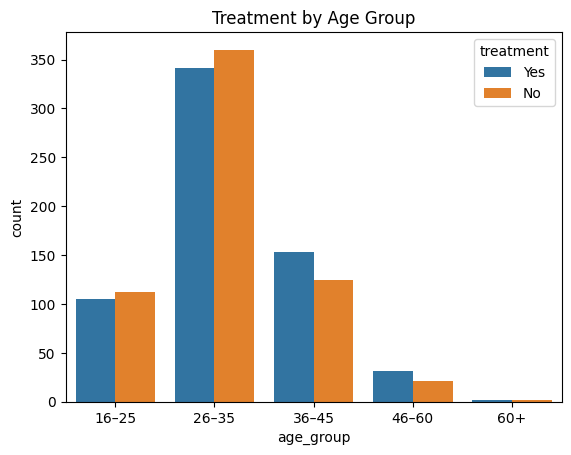

In [19]:
# Filter for realistic age values (already cleaned)
df = df[(df['Age'] > 16) & (df['Age'] < 100)]

# Age Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution of Respondents')
plt.xlabel('Age')
plt.savefig(r"C:\Users\mk199\OneDrive\Desktop\Ronak\Internship\LABMENTEX\Mental Health Survey EDA Analysis\images\Age Distribution of Respondents.png", bbox_inches='tight')
plt.ylabel('Count')
plt.show()

df['age_group'] = pd.cut(df['Age'], bins=[15, 25, 35, 45, 60, 100], labels=['16–25', '26–35', '36–45', '46–60', '60+'])

sns.countplot(x='age_group', hue='treatment', data=df)
plt.title("Treatment by Age Group")
plt.savefig(r"C:\Users\mk199\OneDrive\Desktop\Ronak\Internship\LABMENTEX\Mental Health Survey EDA Analysis\images\Treatment by Age Group.png", bbox_inches='tight')
plt.show()


C:\Users\mk199\AppData\Local\Temp\ipykernel_24052\559836934.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  treatment_percent = df.groupby('age_group')['treatment'].value_counts(normalize=True).unstack() * 100


treatment         No        Yes
age_group                      
16–25      51.612903  48.387097
26–35      51.355207  48.644793
36–45      44.765343  55.234657
46–60      40.384615  59.615385
60+        50.000000  50.000000


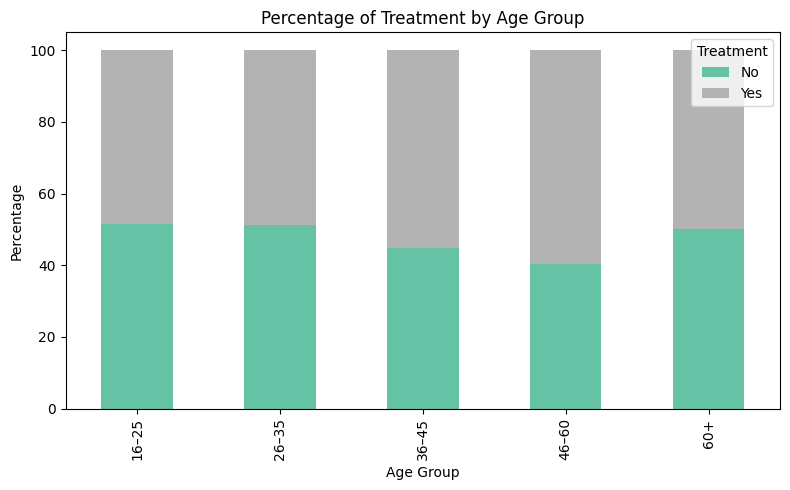

In [20]:
# Percentage of treatment responses within each age group
treatment_percent = df.groupby('age_group')['treatment'].value_counts(normalize=True).unstack() * 100
print(treatment_percent)

# Plot as a stacked bar chart
treatment_percent.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Set2')
plt.title("Percentage of Treatment by Age Group")
plt.ylabel("Percentage")
plt.xlabel("Age Group")
plt.legend(title='Treatment')
plt.tight_layout()
plt.savefig(r"C:\Users\mk199\OneDrive\Desktop\Ronak\Internship\LABMENTEX\Mental Health Survey EDA Analysis\images\treatment_percentage_by_age_group.png", bbox_inches='tight')
plt.show()


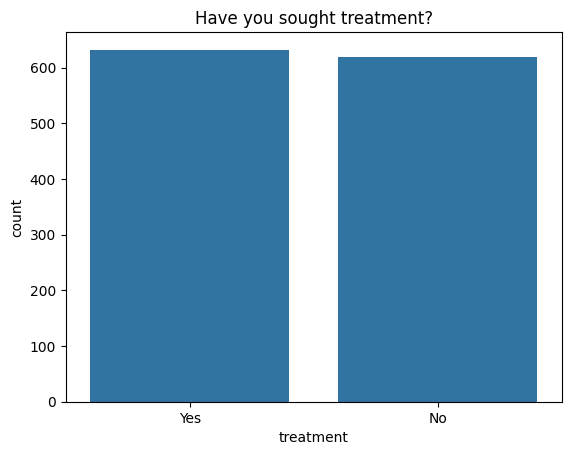

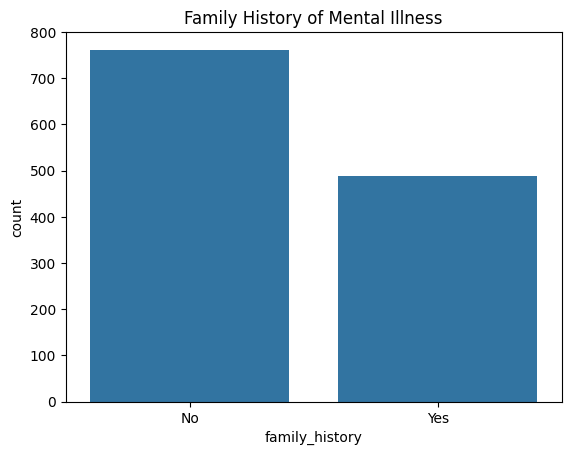

In [21]:
# Count of treatment and family history
sns.countplot(x='treatment', data=df)
plt.title("Have you sought treatment?")
plt.savefig(r"C:\Users\mk199\OneDrive\Desktop\Ronak\Internship\LABMENTEX\Mental Health Survey EDA Analysis\images\Have you sought treatment.png", bbox_inches='tight')
plt.show()

sns.countplot(x='family_history', data=df)
plt.title("Family History of Mental Illness")
plt.savefig(r"C:\Users\mk199\OneDrive\Desktop\Ronak\Internship\LABMENTEX\Mental Health Survey EDA Analysis\images\Family History of Mental Illness.png", bbox_inches='tight')
plt.show()

## 📉 Bivariate Analysis

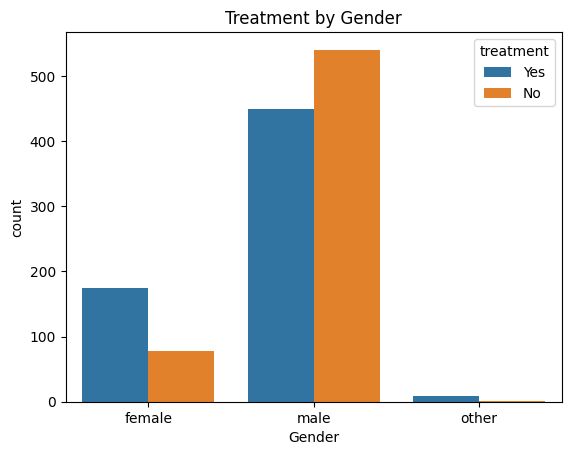

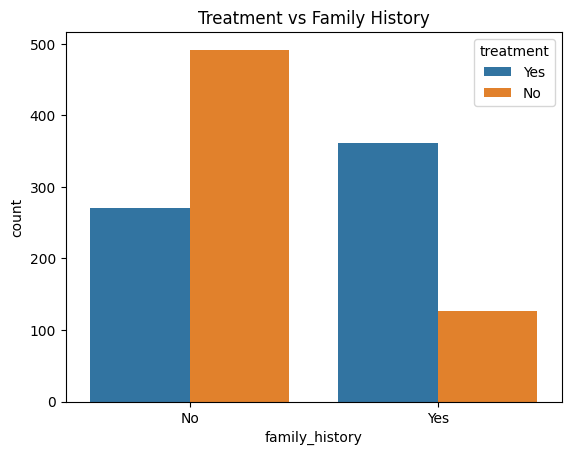

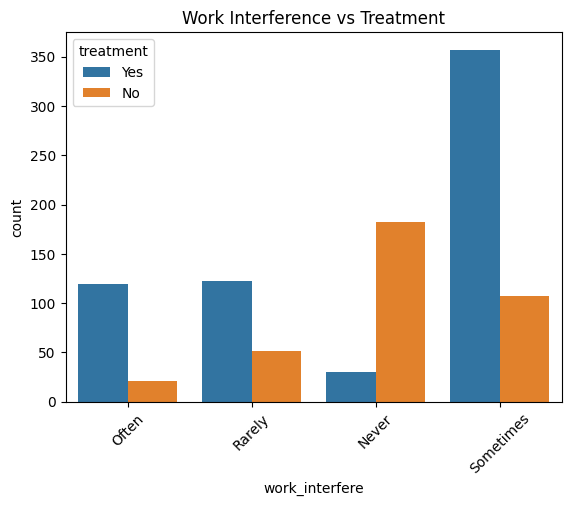

In [22]:
# Treatment vs Gender
sns.countplot(x='Gender', hue='treatment', data=df)
plt.title("Treatment by Gender")
plt.savefig(r"C:\Users\mk199\OneDrive\Desktop\Ronak\Internship\LABMENTEX\Mental Health Survey EDA Analysis\images\Treatment by Gender.png", bbox_inches='tight')
plt.show()

# Treatment vs Family History
sns.countplot(x='family_history', hue='treatment', data=df)
plt.title("Treatment vs Family History")
plt.savefig(r"C:\Users\mk199\OneDrive\Desktop\Ronak\Internship\LABMENTEX\Mental Health Survey EDA Analysis\images\Treatment vs Family History.png", bbox_inches='tight')
plt.show()

# Treatment vs Work Interference
sns.countplot(x='work_interfere', hue='treatment', data=df)
plt.title("Work Interference vs Treatment")
plt.xticks(rotation=45)
plt.savefig(r"C:\Users\mk199\OneDrive\Desktop\Ronak\Internship\LABMENTEX\Mental Health Survey EDA Analysis\images\Work Interference vs Treatment.png", bbox_inches='tight')
plt.show()

## 🌍 Country-wise Mental Health Treatment

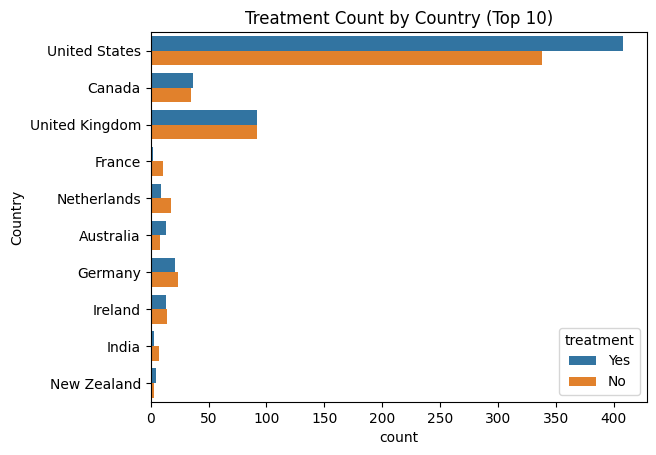

In [23]:
top_countries = df['Country'].value_counts().head(10).index
sns.countplot(data=df[df['Country'].isin(top_countries)], y='Country', hue='treatment')
plt.title("Treatment Count by Country (Top 10)")
plt.savefig(r"C:\Users\mk199\OneDrive\Desktop\Ronak\Internship\LABMENTEX\Mental Health Survey EDA Analysis\images\Treatment Count by Country (Top 10).png", bbox_inches='tight')
plt.show()

## 🏢 Mental Health Support in Organizations

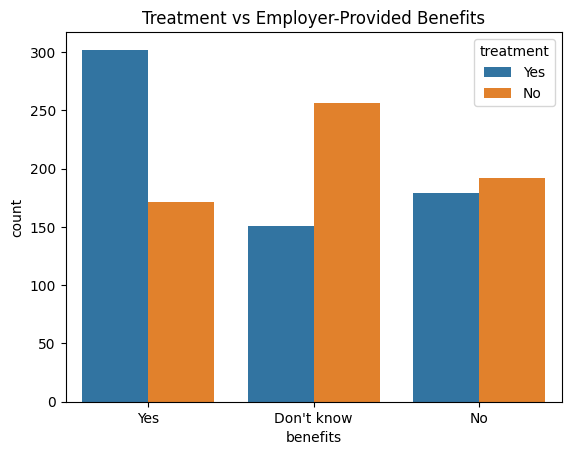

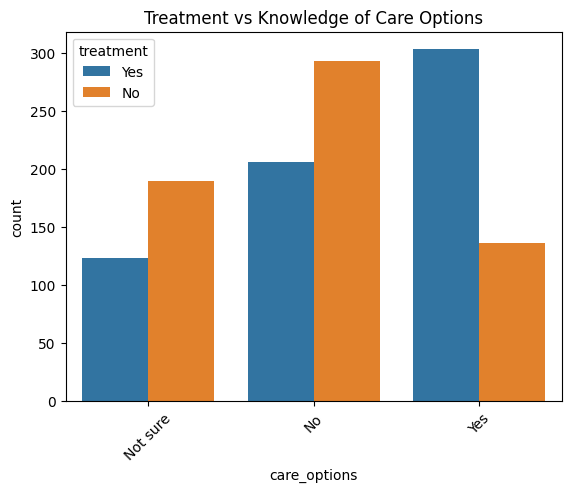

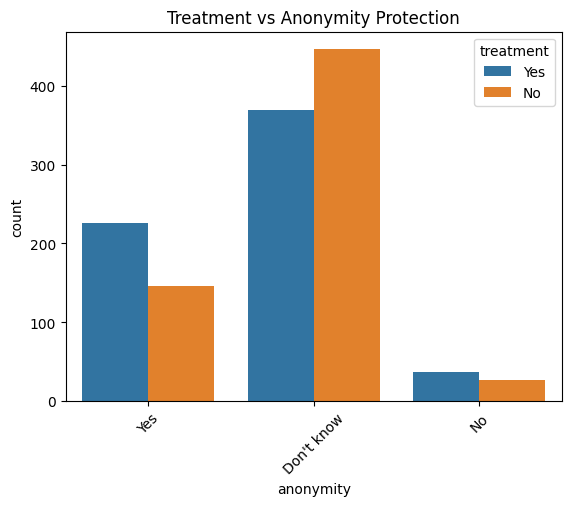

In [24]:
# Benefits vs Treatment
sns.countplot(x='benefits', hue='treatment', data=df)
plt.title("Treatment vs Employer-Provided Benefits")
plt.savefig(r"C:\Users\mk199\OneDrive\Desktop\Ronak\Internship\LABMENTEX\Mental Health Survey EDA Analysis\images\Treatment vs Employer-Provided Benefits.png", bbox_inches='tight')
plt.show()

# Care options
sns.countplot(x='care_options', hue='treatment', data=df)
plt.title("Treatment vs Knowledge of Care Options")
plt.xticks(rotation=45)
plt.savefig(r"C:\Users\mk199\OneDrive\Desktop\Ronak\Internship\LABMENTEX\Mental Health Survey EDA Analysis\images\Treatment vs Knowledge of Care Options.png", bbox_inches='tight')
plt.show()

# Anonymity
sns.countplot(x='anonymity', hue='treatment', data=df)
plt.title("Treatment vs Anonymity Protection")
plt.xticks(rotation=45)
plt.savefig(r"C:\Users\mk199\OneDrive\Desktop\Ronak\Internship\LABMENTEX\Mental Health Survey EDA Analysis\images\Treatment vs Anonymity Protection.png", bbox_inches='tight')
plt.show()

## ✅ Key Takeaways
- Younger tech employees are more represented in the survey.
- Males dominate the dataset, though there's significant gender diversity.
- Family history strongly correlates with seeking treatment.
- Organizational factors like mental health benefits, care options awareness, and anonymity significantly influence treatment seeking.
- Work interference due to mental health is a key driver in treatment behavior.

